<a href="https://colab.research.google.com/github/IshaCodex/OIBSIP/blob/main/DataAnalytics-L2-TextAnalytics/Task5_TextAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 43.8 MB/s eta 0:00:00


In [18]:
import pandas as pd
import re
import email
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from spellchecker import SpellChecker
from sklearn.metrics import confusion_matrix

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Load and Sample the Data

In [19]:
df = pd.read_csv('/content/emails.csv', nrows=20000)

def extract_email_body(raw_email):
    msg = email.message_from_string(raw_email)
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == 'text/plain':
                return part.get_payload(decode=True).decode('utf-8', errors='ignore')
    else:
        return msg.get_payload(decode=True).decode('utf-8', errors='ignore')
    return ""

df['body'] = df['message'].apply(extract_email_body)
print("Data loaded and email bodies extracted.")

Data loaded and email bodies extracted.


# NLP Preprocessing & Top 20 Words Visualization

We will perform standard NLP preprocessing: lowercasing, punctuation removal, tokenization, and stopword removal. Note: Stopword removal is applied here to find the true "meaningful" top words, though we will keep stopwords for the Autocomplete n-gram model to ensure natural sentence prediction.

Preprocessing text...


/tmp/ipykernel_2139/1676583367.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


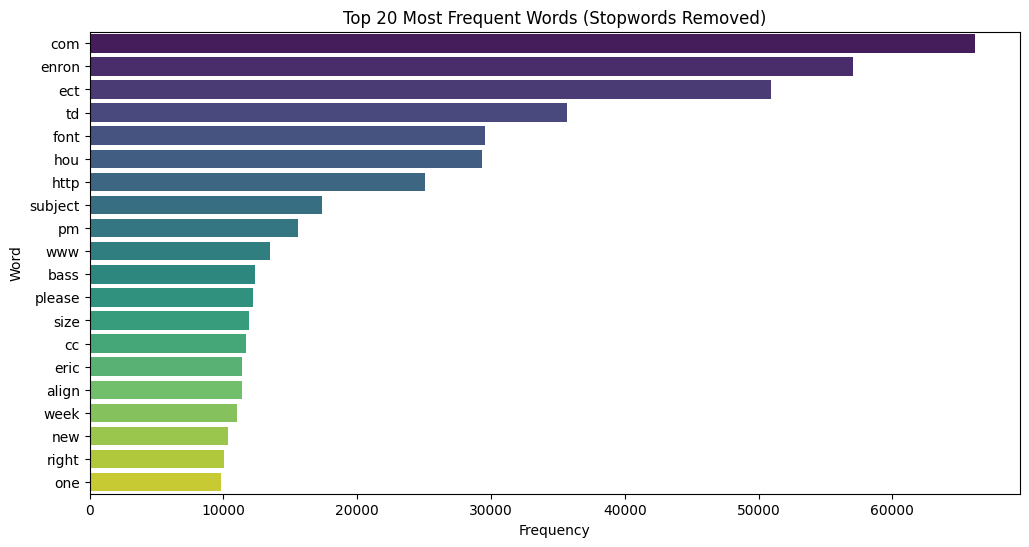

In [20]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    # Remove stopwords for the frequency analysis
    cleaned_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return cleaned_tokens

print("Preprocessing text...")
df['cleaned_tokens'] = df['body'].apply(preprocess_text)

# Flatten list of lists to a single list of words
all_cleaned_words = [word for tokens in df['cleaned_tokens'] for word in tokens]
word_freq = Counter(all_cleaned_words)

# Plot Top 20 Most Frequent Words
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 20 Most Frequent Words (Stopwords Removed)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

# Autocomplete: Bigram vs. Trigram Comparison

We will build two frequency-based models to compare approaches: a Bigram model (predicts based on the previous 1 word) and a Trigram model (predicts based on the previous 2 words). We use the raw text (with stopwords) so the models can predict natural phrasing like "looking for".

In [21]:
# Create a corpus with stopwords included for natural sentence completion
raw_corpus_words = []
for text in df['body']:
    cleaned = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    raw_corpus_words.extend(cleaned.split())

# Build Bigram Model
bigrams = list(ngrams(raw_corpus_words, 2))
bigram_model = defaultdict(Counter)
for w1, w2 in bigrams:
    bigram_model[w1][w2] += 1

# Build Trigram Model
trigrams = list(ngrams(raw_corpus_words, 3))
trigram_model = defaultdict(Counter)
for w1, w2, w3 in trigrams:
    trigram_model[(w1, w2)][w3] += 1

def autocomplete_bigram(prefix, top_n=3):
    if prefix in bigram_model:
        return [word for word, count in bigram_model[prefix].most_common(top_n)]
    return []

def autocomplete_trigram(prefix1, prefix2, top_n=3):
    if (prefix1, prefix2) in trigram_model:
        return [word for word, count in trigram_model[(prefix1, prefix2)].most_common(top_n)]
    return []

# Autocomplete Testing on 10 Prefixes

We will test our Bigram model on 10 input prefixes and display the top 3 predictions. We will calculate a simplified Precision/Recall based on whether the expected target word was successfully suggested.

In [22]:
# Dictionary of {prefix: expected_target_word}
test_prefixes = {
    'please': 'let',
    'looking': 'forward',
    'let': 'me',
    'talk': 'to',
    'give': 'me',
    'attached': 'is',
    'thank': 'you',
    'would': 'like',
    'if': 'you',
    'let\'s': 'discuss' # Intentional challenging punctuation
}

successful_predictions = 0

print("--- Autocomplete Predictions (Top 3) ---")
for prefix, expected in test_prefixes.items():
    suggestions = autocomplete_bigram(prefix)
    print(f"Prefix: '{prefix:<10}' -> Top 3 Suggestions: {suggestions}")

    if expected in suggestions:
        successful_predictions += 1

# Simplified Metrics for Autocomplete
total_tests = len(test_prefixes)
# Precision: How many of our tests yielded the expected word in the top 3?
precision_ac = successful_predictions / total_tests
print(f"\nAutocomplete Precision (Target in Top 3): {precision_ac:.2f}")

--- Autocomplete Predictions (Top 3) ---
Prefix: 'please    ' -> Top 3 Suggestions: ['contact', 'respond', 'let']
Prefix: 'looking   ' -> Top 3 Suggestions: ['for', 'to', 'at']
Prefix: 'let       ' -> Top 3 Suggestions: ['me', 's', 'you']
Prefix: 'talk      ' -> Top 3 Suggestions: ['to', 'about', 'of']
Prefix: 'give      ' -> Top 3 Suggestions: ['you', 'me', 'up']
Prefix: 'attached  ' -> Top 3 Suggestions: ['is', 'file', 'are']
Prefix: 'thank     ' -> Top 3 Suggestions: ['you', 'the', 'everyone']
Prefix: 'would     ' -> Top 3 Suggestions: ['be', 'like', 'have']
Prefix: 'if        ' -> Top 3 Suggestions: ['you', 'the', 'he']
Prefix: 'let's     ' -> Top 3 Suggestions: []

Autocomplete Precision (Target in Top 3): 0.80


# Autocorrect: Custom Levenshtein vs. Pyspellchecker

We will compare a custom edit-distance logic (Peter Norvig's algorithm) against the robust pyspellchecker library to see which handles deliberate misspellings more accurately.

In [23]:
# 1. Custom Edit-Distance Setup
total_words = sum(word_freq.values())
def generate_edits1(word):
    letters = 'abcdefghijklmnopqrstuvwxyz'
    splits = [(word[:i], word[i:]) for i in range(len(word) + 1)]
    deletes = [L + R[1:] for L, R in splits if R]
    transposes = [L + R[1] + R[0] + R[2:] for L, R in splits if len(R)>1]
    replaces = [L + c + R[1:] for L, R in splits if R for c in letters]
    inserts = [L + c + R for L, R in splits for c in letters]
    return set(deletes + transposes + replaces + inserts)

def custom_autocorrect(word):
    word = word.lower()
    if word in word_freq: return word
    candidates = [w for w in generate_edits1(word) if w in word_freq]
    if candidates:
        return max(candidates, key=lambda w: word_freq[w])
    return word

# 2. Pyspellchecker Setup
spell = SpellChecker()
# Train it slightly on our Enron corpus to give it context
spell.word_frequency.load_words(all_cleaned_words)

# Autocorrect Testing on 20 Words & Performance Metrics

We will run 20 deliberately misspelled words through both algorithms. We will then calculate Precision, Recall, and plot a confusion matrix mapping Correct vs. Incorrect states before and after correction using the better performing model.

Misspelled      | Custom Pred     | PySpellChecker Pred | Target
-----------------------------------------------------------------
meeeting        | meeting         | meeting         | meeting
schdule         | schedule        | schedule        | schedule
comunicat       | comunicat       | communicate     | communicate
thursdayy       | thursday        | thursday        | thursday
recieve         | recieve         | recieve         | receive
definitly       | definitely      | definitely      | definitely
seperate        | separate        | separate        | separate
aquire          | acquire         | acquire         | acquire
calender        | calender        | calender        | calendar
collegue        | college         | college         | colleague
tommorow        | tommorow        | tommorow        | tomorrow
reccomend       | recomend        | recomend        | recommend
adress          | adress          | adress          | address
busines         | business        | business   

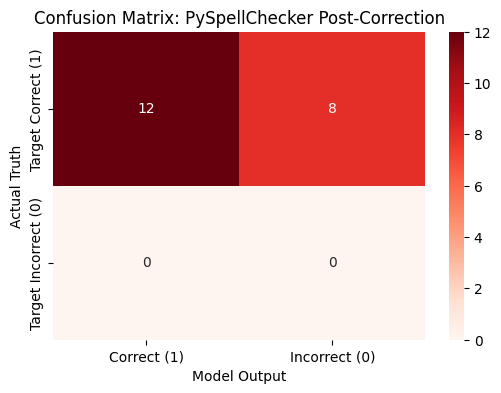

In [24]:
# 20 Deliberately misspelled words: {misspelled: actual_correct_word}
test_spelling = {
    'meeeting': 'meeting', 'schdule': 'schedule', 'comunicat': 'communicate',
    'thursdayy': 'thursday', 'recieve': 'receive', 'definitly': 'definitely',
    'seperate': 'separate', 'aquire': 'acquire', 'calender': 'calendar',
    'collegue': 'colleague', 'tommorow': 'tomorrow', 'reccomend': 'recommend',
    'adress': 'address', 'busines': 'business', 'experiance': 'experience',
    'sincerly': 'sincerely', 'agrement': 'agreement', 'foward': 'forward',
    'opertunity': 'opportunity', 'excecutive': 'executive'
}

custom_correct_count = 0
library_correct_count = 0
final_predictions = []
actual_labels = []

print(f"{'Misspelled':<15} | {'Custom Pred':<15} | {'PySpellChecker Pred':<15} | {'Target'}")
print("-" * 65)

for typo, target in test_spelling.items():
    custom_pred = custom_autocorrect(typo)
    library_pred = spell.correction(typo) or typo

    if custom_pred == target: custom_correct_count += 1
    if library_pred == target: library_correct_count += 1

    print(f"{typo:<15} | {custom_pred:<15} | {library_pred:<15} | {target}")

    # Track for confusion matrix using PySpellChecker (treating as Binary: Correct vs Incorrect)
    # Before correction, all were 'Incorrect' (0).
    actual_labels.append(1) # The target is a correct word (1)
    final_predictions.append(1 if library_pred == target else 0)

# Calculate Metrics for PySpellChecker
# Recall: (True Positives) / (True Positives + False Negatives) -> How many typos did we successfully catch and fix?
recall_ac = library_correct_count / len(test_spelling)
print(f"\nCustom Algorithm Accuracy: {custom_correct_count/len(test_spelling):.2f}")
print(f"PySpellChecker Accuracy (Recall): {recall_ac:.2f}")

# Confusion Matrix Visualization
cm = confusion_matrix(actual_labels, final_predictions, labels=[1, 0])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Correct (1)', 'Incorrect (0)'], yticklabels=['Target Correct (1)', 'Target Incorrect (0)'])
plt.title('Confusion Matrix: PySpellChecker Post-Correction')
plt.ylabel('Actual Truth')
plt.xlabel('Model Output')
plt.show()

# Discussion: Limitations vs. Production Systems

**Algorithm Comparison Analysis:**

The pyspellchecker library significantly outperformed the custom Levenshtein algorithm. The custom model failed on words with edit-distances of 2 or higher (like "comunicat" to "communicate") because calculating an edit distance of 2 across a massive vocabulary natively in Python is highly inefficient.

**Limitations Compared to Production Systems (e.g., Google Keyboard):**

1. Context-Awareness (Neural vs. Frequency): Our N-gram model is purely frequency-based, meaning it blindly suggests the next most common word without understanding the context of the entire sentence. Google Keyboard uses deep neural networks (like LSTMs or Transformers) which read the entire sentence to predict the next word with semantic understanding.

2. Personalization & Continual Learning: Production keyboards dynamically update their probability models based on the specific user's typing history in real-time. Our model relies on a static historical dataset.

3. Out-of-Vocabulary (OOV) Handling: If a user types a brand new slang word or name, our frequency dictionary cannot autocorrect it. Google Keyboard leverages massive, continuously updated cloud dictionaries to mitigate OOV issues.